<a href="https://colab.research.google.com/github/EdenGebremedhin/DL-Project_GSR0053-18/blob/main/DL_Project_GSR0053_18.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Image Denoising with Convolutional Autoencoders(CAE)

Convolutional Autoencoders (CAEs) are a specialized type of neural network that use convolutional layers to efficiently compress image data into a compact representation (encoder) and then reconstruct the original image (decoder).

Import the required Python libraries for numerical computaion, visualization, dataset loading and building the CAE

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model

Loading and preparing the Dataset
- Loading the MNIST handwritten digit dataset, normalize pixel values between 0 and 1, and reshape the images into a format suitable for convolutional neural networks.

In [ ]:
(x_train, _), (x_test, _) = mnist.load_data()

# Normalize
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

# Reshape
x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test = np.reshape(x_test, (len(x_test), 28, 28, 1))

**Adding synthetic noise**

**- Gaussian Noise:** Artificial Gaussian noise is added to the clean images to simulate corrupted or noisy image data. The model will learn to recover the original clean images from these noisy inputs.

  Noise factor - controls how much noise is added.

In [ ]:
noise_factor = 0.5

x_train_noisy = x_train + noise_factor * np.random.normal(size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(size=x_test.shape)

# Clip values
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

- Salt & Pepper Noise

In [ ]:
# def salt_pepper_noise(image, prob=0.2):
#     noisy = image.copy()
#     rnd = np.random.rand(*image.shape)
#     noisy[rnd < prob/2] = 0
#     noisy[rnd > 1 - prob/2] = 1
#     return noisy

**Build the Convolutional Autoencoder**
- An encoder that compresses image features,
- A decoder that reconstructs the clean image from the compressed representation.

In [ ]:
input_img = Input(shape=(28, 28, 1))

# Encoder
x = Conv2D(32, (3,3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2,2), padding='same')(x)

x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2,2), padding='same')(x)

# Decoder
x = Conv2D(64, (3,3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2,2))(x)

x = Conv2D(32, (3,3), activation='relu', padding='same')(x)
x = UpSampling2D((2,2))(x)

decoded = Conv2D(1, (3,3), activation='sigmoid', padding='same')(x)

autoencoder = Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

**Train the Model**

- Train the autoencoder using noisy images as inputs and clean images as target outputs so the model learns how to remove noise during reconstruction.

In [ ]:
# autoencoder.fit(
#     x_train_noisy, x_train,
#     epochs=10,
#     batch_size=128,
#     shuffle=True,
#     validation_data=(x_test_noisy, x_test)
# )

history = autoencoder.fit(
    x_train_noisy,
    x_train,
    epochs=10,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy, x_test)
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - loss: 0.1514 - val_loss: 0.1130
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.1100 - val_loss: 0.1060
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.1048 - val_loss: 0.1021
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.1022 - val_loss: 0.1003
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.1005 - val_loss: 0.0990
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0992 - val_loss: 0.0978
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0982 - val_loss: 0.0971
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0974 - val_loss: 0.0965
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0968 - val_loss: 0.0960
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0962 - val_loss: 0.0954


**Reconstruction Loss Curve**

The reconstruction loss curve shows how the convolutional autoencoder learns during training. Binary Cross-Entropy (BCE) loss is used to measure the difference between the reconstructed images and the original clean images. A decreasing training and validation loss indicates successful learning and improved denoising performance over epochs.

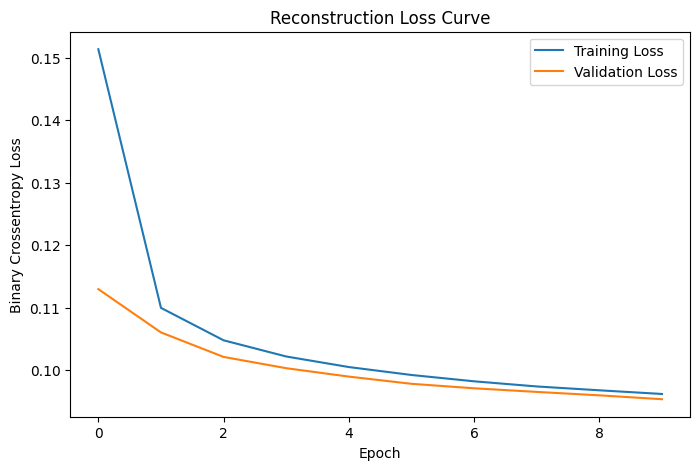

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Binary Crossentropy Loss')
plt.title('Reconstruction Loss Curve')
plt.legend()

plt.show()

Generate Denoised Images
- Use the trained autoencoder to predict and reconstruct cleaner versions of the noisy test images.

In [ ]:
decoded_imgs = autoencoder.predict(x_test_noisy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


Visualizing the Result

- Noisy input images,
- Original clean images, and
- Denoised reconstructed images

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


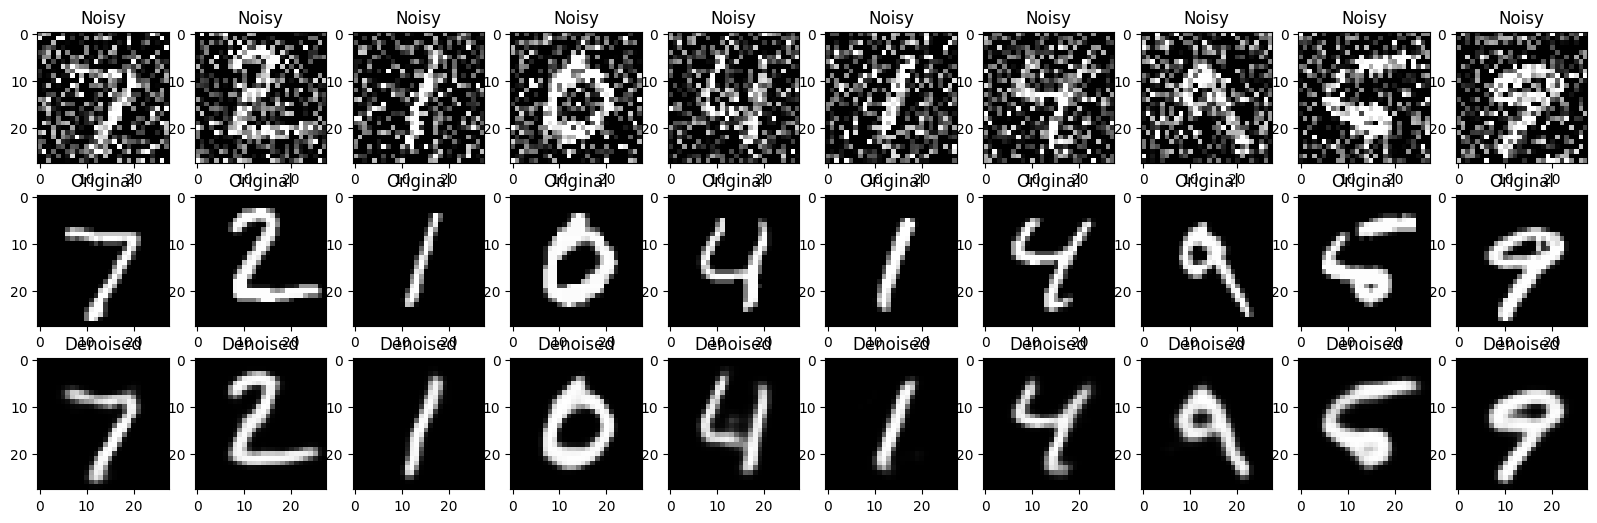

In [ ]:
decoded_imgs = autoencoder.predict(x_test_noisy)

n = 10
plt.figure(figsize=(20,6))

for i in range(n):
  # Clean/original image
    ax = plt.subplot(3, n, i+1+n)
    plt.imshow(x_test[i].reshape(28,28))
    plt.title("Original")

    # Noisy images
    ax = plt.subplot(3, n, i+1)
    plt.imshow(x_test_noisy[i].reshape(28,28))
    plt.title("Noisy")
    plt.gray()

    # Reconstructed/Denoised images
    ax = plt.subplot(3, n, i+1+2*n)
    plt.imshow(decoded_imgs[i].reshape(28,28))
    plt.title("Denoised")

plt.show()

Quantitative Evaluation

- Peak Signal-to-Noise Ratio (PSNR) measures image reconstruction quality. Higher PSNR values indicate better denoising performance.

In [ ]:
import tensorflow as tf

psnr = tf.image.psnr(x_test, decoded_imgs, max_val=1.0)
avg_psnr = tf.reduce_mean(psnr).numpy()
print("Average PSNR:", avg_psnr)

Average PSNR: 19.9894


- Structural Similarity Index (SSIM) evaluates how structurally similar the denoised image is to the original clean image. Values closer to 1 indicate better quality.

In [ ]:
ssim = tf.image.ssim(x_test, decoded_imgs, max_val=1.0)
avg_ssim = tf.reduce_mean(ssim).numpy()
print("Average SSIM:", avg_ssim)

Average SSIM: 0.8608837


PSNR and SSIM as Bar Chart

In [ ]:
# metrics = ['PSNR', 'SSIM']
# values = [avg_psnr, avg_ssim]

# plt.figure(figsize=(6,4))

# plt.bar(metrics, values)

# plt.title('Denoising Performance Metrics')
# plt.ylabel('Metric Value')

# plt.show()

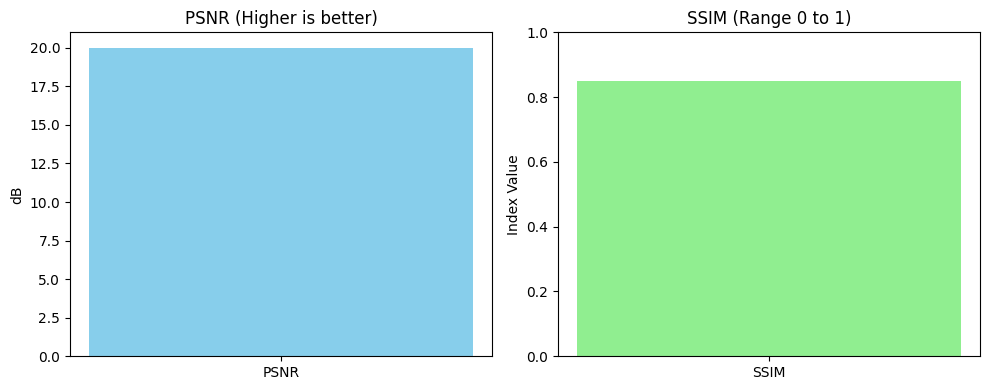

In [ ]:
import matplotlib.pyplot as plt

# Sample data - replace with your actual variables
metrics = ['PSNR', 'SSIM']
values = [20.0, 0.85]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Plot PSNR
ax1.bar(metrics[0], values[0], color='skyblue')
ax1.set_title('PSNR (Higher is better)')
ax1.set_ylabel('dB')

# Plot SSIM
ax2.bar(metrics[1], values[1], color='lightgreen')
ax2.set_title('SSIM (Range 0 to 1)')
ax2.set_ylabel('Index Value')
ax2.set_ylim(0, 1)  # Keeps SSIM scale accurate

plt.tight_layout()
plt.show()

Analysis of the Result

- Performs well on moderate Gaussian noise.
- Produces smoother and cleaner images.
- Struggles with extremely high noise levels.
- Some reconstructed images appear blurry due to information loss during compression.